데이터 전처리 완료! 데이터 개수: 19671


,총 운항,총 공급,총 여객,L/F
count,19671.00,19671.00,19671.00,19671.00
mean,67.36,15315.52,11745.98,0.76
std,54.30,13411.03,10837.81,0.16
min,0.00,13.00,0.00,0.00
25%,34.00,6615.00,4705.50,0.67
50%,60.00,11362.00,9108.00,0.80
75%,63.00,18910.00,14211.00,0.88
max,434.00,93463.00,80744.00,1.00


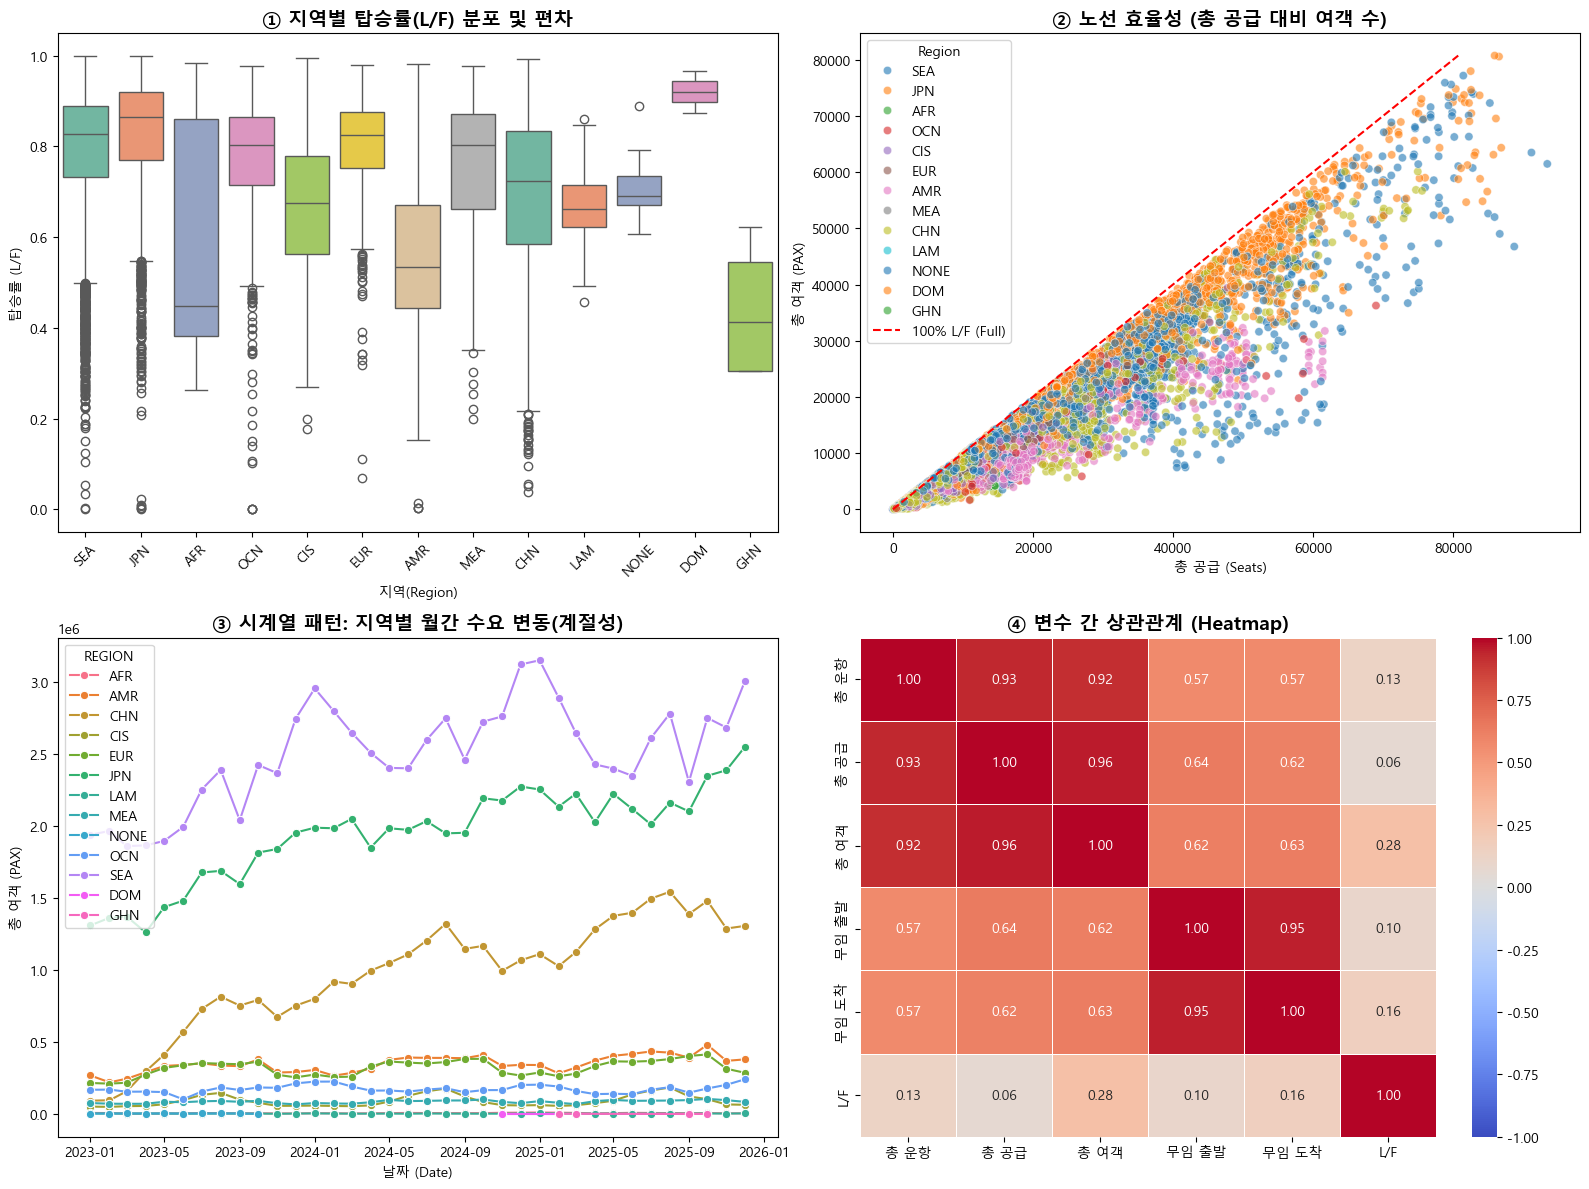

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 💡 한글 폰트 깨짐 방지 (윈도우 맑은 고딕 기준)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

# 1. 데이터 불러오기 및 기본 전처리
df = pd.read_csv('../data/항공통계 자료_int.csv')

# 화물기 제외 (여객기만 필터링)
df = df[df['여객/화물'] == '여객기'].copy()

# 콤마(,)가 포함된 문자열 숫자형으로 변환
cols_to_clean = ['여객 출발', '여객 도착', '공급 출발', '공급 도착', '총 여객', '총 공급', '총 운항']
for col in cols_to_clean:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.replace(',', '').astype(float)
    else:
        df[col] = df[col].astype(float)

# '총 공급'이 0이거나 결측치인 비정상 운항 제거 (분모 0 방지)
df = df[(df['총 공급'].notna()) & (df['총 공급'] > 0)]

# 탑승률(L/F) 계산 및 이상치(1.0 초과) 캡핑
df['L/F'] = df['총 여객'] / df['총 공급']
df['L/F'] = df['L/F'].clip(upper=1.0)

# 시계열 분석을 위한 날짜 변환
df['Date'] = pd.to_datetime(df['년월'], format='%b-%y')

print("데이터 전처리 완료! 데이터 개수:", len(df))
display(df[['총 운항', '총 공급', '총 여객', 'L/F']].describe().round(2))

# =========================================================
# 2. 핵심 EDA 시각화 4종 세트
# =========================================================
fig = plt.figure(figsize=(16, 12))

# ① 데이터 분포 파악 (지역별 L/F 박스플롯)
ax1 = fig.add_subplot(2, 2, 1)
sns.boxplot(data=df, x='REGION', y='L/F', palette='Set2', ax=ax1)
ax1.set_title('① 지역별 탑승률(L/F) 분포 및 편차', fontsize=14, fontweight='bold')
ax1.set_xlabel('지역(Region)')
ax1.set_ylabel('탑승률 (L/F)')
ax1.tick_params(axis='x', rotation=45)

# ② 타깃과 주요 변수의 관계 (공급석 vs 여객수 산점도)
ax2 = fig.add_subplot(2, 2, 2)
sns.scatterplot(data=df, x='총 공급', y='총 여객', hue='REGION', alpha=0.6, palette='tab10', ax=ax2)
# 100% L/F 가이드라인 추가
max_val = min(df['총 공급'].max(), df['총 여객'].max())
ax2.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='100% L/F (Full)')
ax2.set_title('② 노선 효율성 (총 공급 대비 여객 수)', fontsize=14, fontweight='bold')
ax2.set_xlabel('총 공급 (Seats)')
ax2.set_ylabel('총 여객 (PAX)')
ax2.legend(title='Region')

# ③ 주요 패턴 및 인사이트 (지역별 월간 여객 수요 추이)
ax3 = fig.add_subplot(2, 2, 3)
monthly_pax = df.groupby(['Date', 'REGION'])['총 여객'].sum().reset_index()
sns.lineplot(data=monthly_pax, x='Date', y='총 여객', hue='REGION', marker='o', ax=ax3)
ax3.set_title('③ 시계열 패턴: 지역별 월간 수요 변동(계절성)', fontsize=14, fontweight='bold')
ax3.set_xlabel('날짜 (Date)')
ax3.set_ylabel('총 여객 (PAX)')

# ④ 변수 간 상관관계 (히트맵)
ax4 = fig.add_subplot(2, 2, 4)
corr_cols = ['총 운항', '총 공급', '총 여객', '무임 출발', '무임 도착', 'L/F']
# 무임승객 콤마 제거
for col in ['무임 출발', '무임 도착']:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.replace(',', '').astype(float)
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, ax=ax4, linewidths=0.5)
ax4.set_title('④ 변수 간 상관관계 (Heatmap)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 항공 여객 수요 데이터 분석 및 예측 (EDA 및 전처리)

## 1. 분석 배경 및 목적
- **비즈니스 목표:** 한정된 항공기 자원(Capacity) 대비 최대의 수익(Revenue)을 창출하기 위해, 노선별/지역별 여객 수요(PAX) 추이를 파악하고 탑승률(L/F)을 최적화할 수 있는 인사이트를 도출한다.
- **분석 방법론:** KDD / SEMMA 방법론에 입각하여, 원본 데이터에서 불필요한 노이즈(비정상 운항 등)를 제거하고 모델링에 적합한 형태로 가공한다.

---

## 2. 데이터 기본 전처리 (Data Modification)
*(이 아래에 1번 전처리 코드를 배치합니다)*

**[전처리 핵심 의사결정]**
1. **대상 세분화:** 화물기 데이터는 여객 수요 예측이라는 본 목적과 부합하지 않으므로 데이터셋에서 제외함.
2. **비정상 데이터 제거:** 공급석이 0이거나 결측치인 비정상 페리(Ferry) 운항 건을 제거하여 모델의 학습 노이즈를 방지함.
3. **타겟 변수 정제:** 단순 총 여객(PAX)뿐만 아니라, 수익 관리(RM)의 핵심 지표인 **탑승률(L/F)**을 파생 변수로 생성하고, 이상치(Overbooking 등으로 인한 1.0 초과)를 캡핑함.

---

## 3. 탐색적 데이터 분석 (EDA) 및 비즈니스 인사이트
*(이 아래에 4분할 시각화 코드를 배치합니다)*

### 시각화 결과 해석 및 도메인 인사이트
1. **지역별 탑승률 편차 (Boxplot):** - 일본(JPN) 및 동남아(SEA) 노선은 1년 내내 안정적인 고수요를 유지하는 핵심 '캐시카우' 역할을 하고 있음. 반면 일부 장거리 노선은 편차가 크므로 탄력적인 기재 투입 전략이 요구됨.
2. **노선별 운항 효율성 (Scatter Plot):**
   - 대부분의 노선이 100% L/F 가이드라인에 근접해 있으나, 공급 대비 여객이 저조한 일부 비효율 노선이 식별됨. 예측 모델을 통해 이 비효율을 사전에 감지하고 공급을 조절해야 함.
3. **시계열 계절성 패턴 (Line Plot):**
   - 7~8월(여름 휴가철)과 12~1월(겨울 방학)에 수요가 급증하는 뚜렷한 **계절성(Seasonality)**이 확인됨. 이는 향후 ARIMA 등 시계열 예측 모델과 트리 기반 머신러닝(RandomForest, XGBoost)을 구축할 때 강력한 예측 피처(Feature)로 작용할 것임.

---

## 4. Next Step: 모델링을 위한 심화 전처리 (Out/In 분리)
- 월 단위 데이터의 특성상 발생하는 '월말-월초 이월 효과(Spill-over)'를 모델이 학습할 수 있도록, 현재 Wide Form으로 되어 있는 출발(Out)/도착(In) 데이터를 Long Form으로 분리하는 추가 전처리를 진행할 예정임.